In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("marketing_campaign_dataset.csv")

df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [4]:
df_clean = df.copy()

print("Backup created successfully.")

Backup created successfully.


# Missing Value Treatment

In [5]:
missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": round(df_clean.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
Campaign_ID,0,0.0
Company,0,0.0
Campaign_Type,0,0.0
Target_Audience,0,0.0
Duration,0,0.0
Channel_Used,0,0.0
Conversion_Rate,0,0.0
Acquisition_Cost,0,0.0
ROI,0,0.0
Location,0,0.0


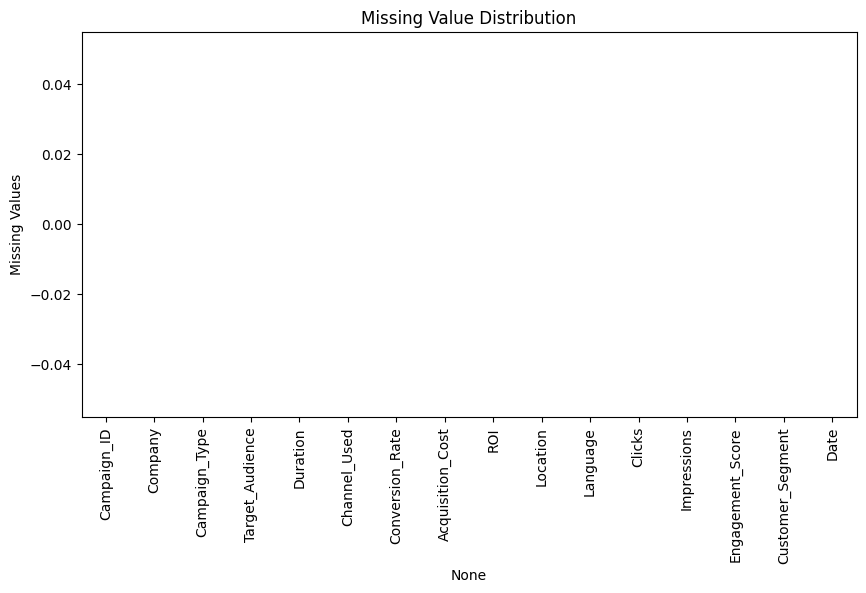

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing["Missing Values"],
    color="steelblue"
)

plt.xticks(rotation=90)

plt.title("Missing Value Distribution")

plt.show()

# Duplicate Handling

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

# Data Type Validation

In [8]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [9]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

# String Standardization

In [10]:
cat_cols = df_clean.select_dtypes(include="object").columns

for col in cat_cols:
    df_clean[col] = (
        df_clean[col]
        .str.strip()
        .str.title()
    )

# Date Feature Engineering

In [11]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Month_Name"] = df_clean["Date"].dt.month_name()
df_clean["Quarter"] = df_clean["Date"].dt.quarter
df_clean["Week"] = df_clean["Date"].dt.isocalendar().week
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["Day_Name"] = df_clean["Date"].dt.day_name()
df_clean["Is_Weekend"] = df_clean["Date"].dt.weekday >= 5

# Outlier Detection

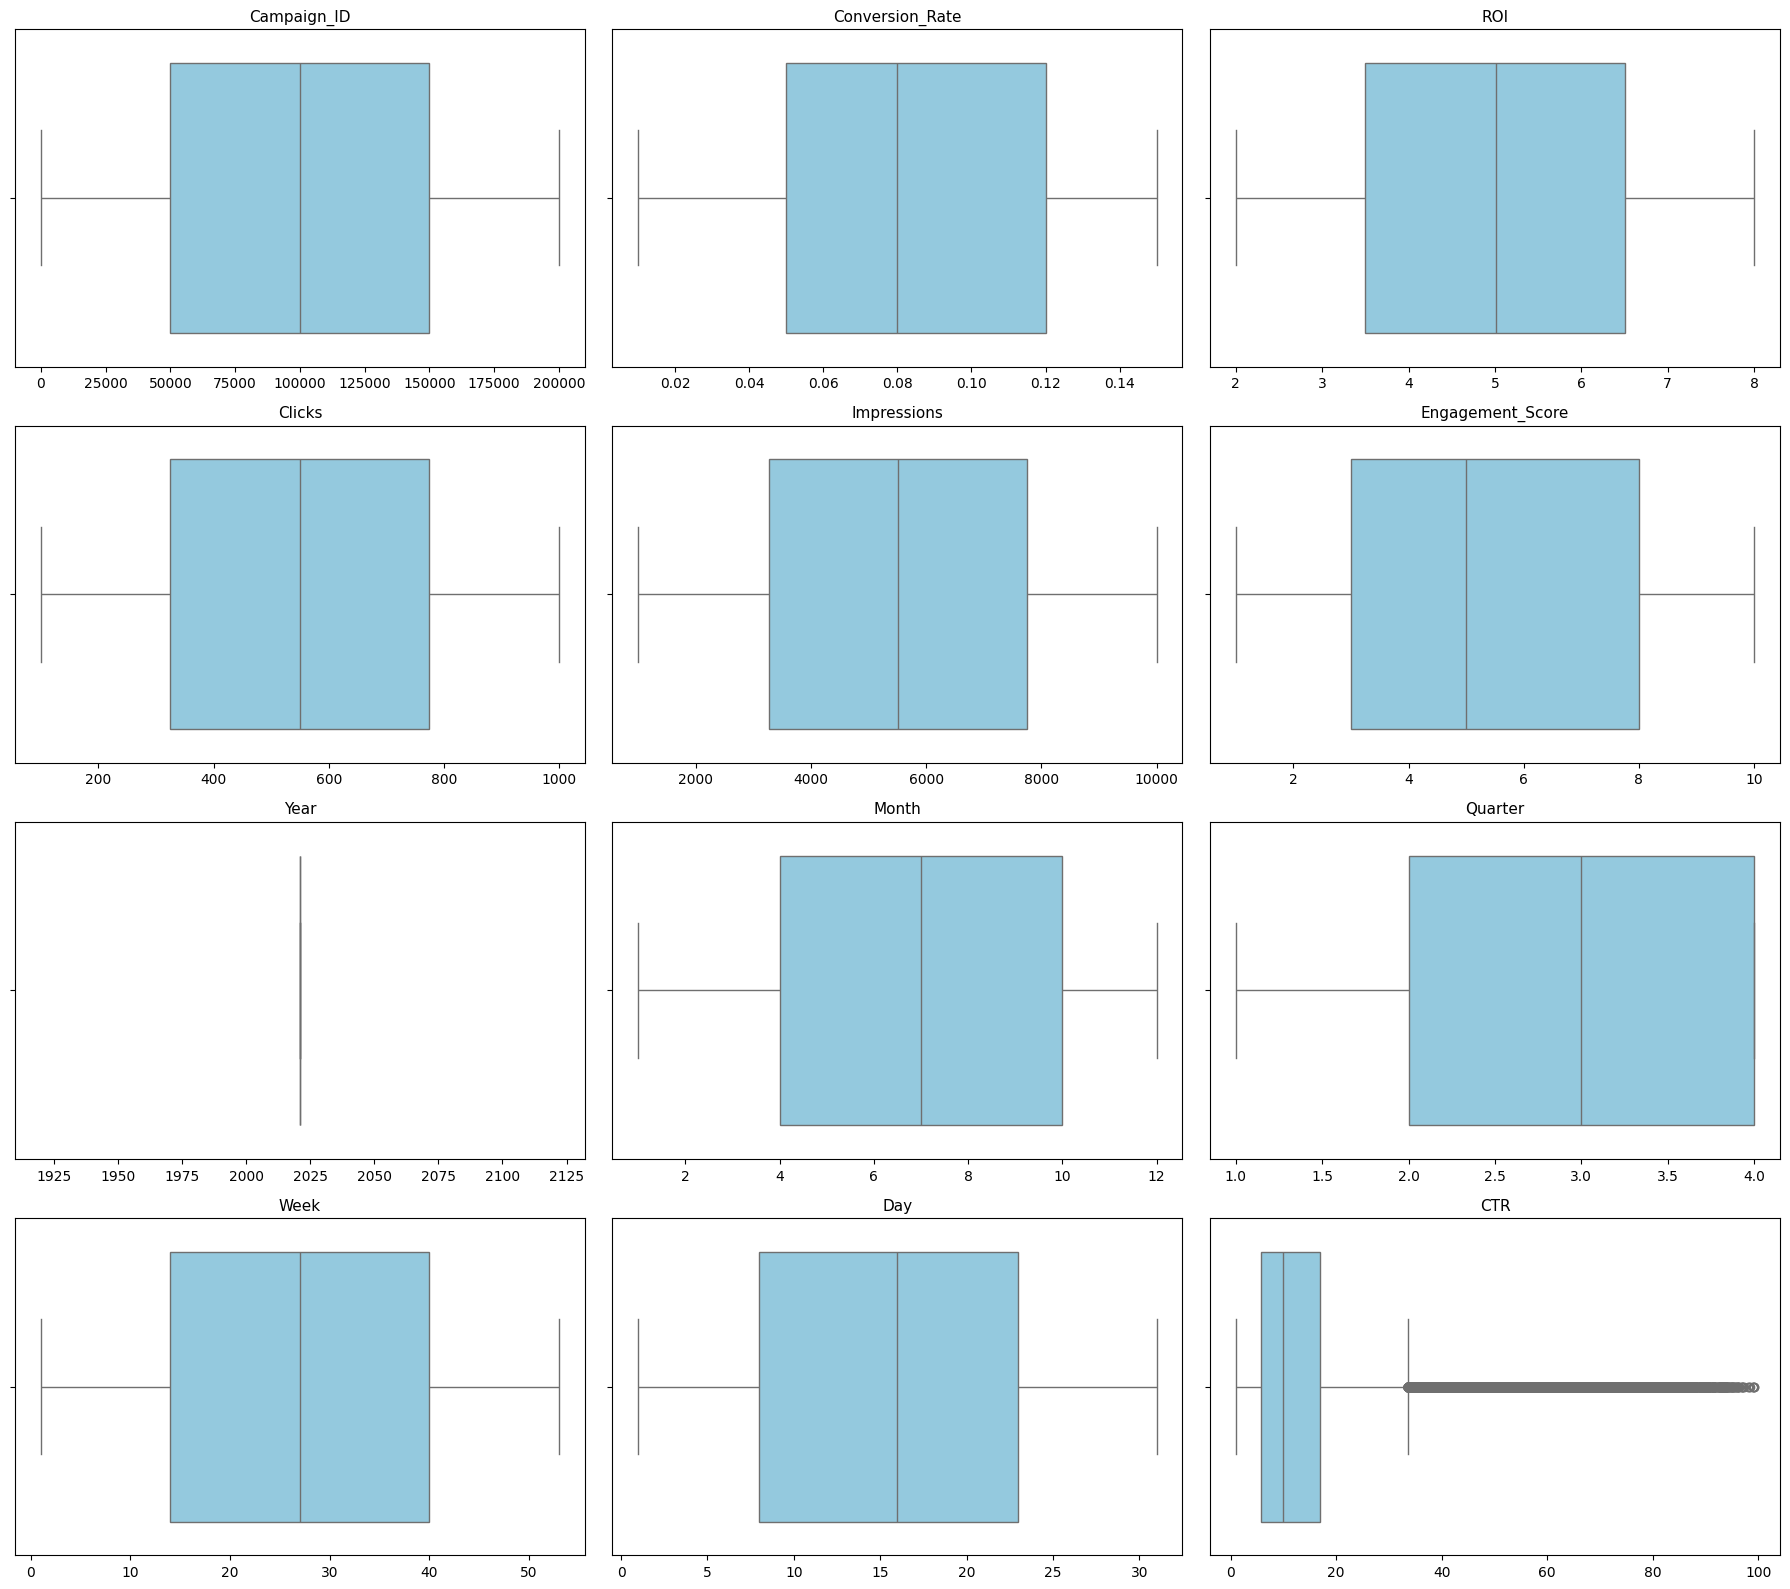

In [18]:
import math

numeric_cols = df_clean.select_dtypes(include=np.number).columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(18, n_rows * 4))

for i, col in enumerate(numeric_cols):

    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        x=df_clean[col],
        color="skyblue"
    )

    plt.title(col, fontsize=11)
    plt.xlabel("")

plt.tight_layout()
plt.show()

# IQR Report

In [13]:
outlier_summary = []

for col in numeric_cols:

    Q1 = df_clean[col].quantile(.25)

    Q3 = df_clean[col].quantile(.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR

    upper = Q3+1.5*IQR

    count = df_clean[
        (df_clean[col]<lower)|
        (df_clean[col]>upper)
    ].shape[0]

    outlier_summary.append([col,count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature","Outliers"]
)

outlier_df

,Feature,Outliers
0,Campaign_ID,0
1,Conversion_Rate,0
2,ROI,0
3,Clicks,0
4,Impressions,0
5,Engagement_Score,0
6,Year,0
7,Month,0
8,Quarter,0
9,Week,0


# Feature Engineering

In [15]:
df_clean["CTR"] = (
    df_clean["Clicks"] /
    df_clean["Impressions"]
)*100

In [16]:
df_clean["CTR"] = (
    df_clean["Clicks"] /
    df_clean["Impressions"]
)*100

In [19]:
df_clean["Acquisition_Cost"].dtype

dtype('O')

In [20]:
df_clean["Acquisition_Cost"] = (
    df_clean["Acquisition_Cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df_clean["Acquisition_Cost"] = pd.to_numeric(
    df_clean["Acquisition_Cost"],
    errors="coerce"
)

In [21]:
df_clean["Acquisition_Cost"].dtype

dtype('float64')

In [22]:
df_clean["CPC"] = (
    df_clean["Acquisition_Cost"] /
    df_clean["Clicks"]
)

In [23]:
currency_cols = ["Acquisition_Cost"]

for col in currency_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )

    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [25]:
df_clean["Engagement_Level"] = pd.qcut(
    df_clean["Engagement_Score"],
    3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [26]:
df_clean["ROI_Level"] = pd.cut(

    df_clean["ROI"],

    bins=[0,3,6,10],

    labels=[
        "Low",
        "Medium",
        "High"
    ]

)

In [27]:
duration_days = {

"30 Days":30,

"60 Days":60,

"90 Days":90,

"180 Days":180

}

df_clean["Campaign_Days"] = (
    df_clean["Duration"]
    .map(duration_days)
)

# Data Consistency Check

In [28]:
print(df_clean.describe())

print(df_clean.info())

         Campaign_ID  Conversion_Rate  Acquisition_Cost            ROI  \
count  200000.000000    200000.000000     200000.000000  200000.000000   
mean   100000.500000         0.080070      12504.393040       5.002438   
min         1.000000         0.010000       5000.000000       2.000000   
25%     50000.750000         0.050000       8739.750000       3.500000   
50%    100000.500000         0.080000      12496.500000       5.010000   
75%    150000.250000         0.120000      16264.000000       6.510000   
max    200000.000000         0.150000      20000.000000       8.000000   
std     57735.171256         0.040602       4337.664545       1.734488   

              Clicks    Impressions  Engagement_Score  \
count  200000.000000  200000.000000     200000.000000   
mean      549.772030    5507.301520          5.494710   
min       100.000000    1000.000000          1.000000   
25%       325.000000    3266.000000          3.000000   
50%       550.000000    5517.500000          5.0

# Feature Scaling

In [29]:
scale_cols = [

"Clicks",

"Impressions",

"Acquisition_Cost",

"ROI",

"CTR",

"CPC"

]

scaler = MinMaxScaler()

df_clean[scale_cols] = scaler.fit_transform(
    df_clean[scale_cols]
)

In [30]:
print("="*60)

print("Missing Values")

print(df_clean.isnull().sum().sum())

print("="*60)

print("Duplicate Rows")

print(df_clean.duplicated().sum())

print("="*60)

print(df_clean.shape)

Missing Values
99879
Duplicate Rows
0
(200000, 29)


In [31]:
df_clean.to_csv(
    "marketing_campaign_cleaned.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully
